# Phase 2 Linear Regression Model

This notebook trains the phase-2 linear model using the selected phase-2 feature set shared with the Random Forest notebook.

It fits two linear variants:

- **OLS Linear Regression**: plain linear regression baseline.
- **Ridge Linear Regression**: linear regression with L2 regularization, used as the primary interpretable model because even deduplicated real-estate features can remain correlated.

The target is `log(next_year_annual_median_sale_price)`. Metrics are reported in both log space and dollars.

In [1]:
from pathlib import Path
import json
import os

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'outputs' / 'phase2-models' / 'model-data').exists()
)

CACHE_DIR = PROJECT_ROOT / 'outputs' / 'cache'
os.environ.setdefault('MPLCONFIGDIR', str(CACHE_DIR / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_DIR / 'xdg'))
(CACHE_DIR / 'matplotlib').mkdir(parents=True, exist_ok=True)
(CACHE_DIR / 'xdg').mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
MODEL_DATA_DIR = PROJECT_ROOT / 'outputs' / 'phase2-models' / 'model-data'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'phase2-models' / 'linear-regression'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 120)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'OUTPUT_DIR: {OUTPUT_DIR}')

PROJECT_ROOT: /Users/charlesgao/Desktop/spring2026/stats170B/project
OUTPUT_DIR: /Users/charlesgao/Desktop/spring2026/stats170B/project/outputs/phase2-models/linear-regression


## Load Selected Model Data

In [2]:
train = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_train_2012_2022.csv', dtype={'zcta5': str}, low_memory=False)
test = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_test_2023.csv', dtype={'zcta5': str}, low_memory=False)
feature_schema = pd.read_csv(MODEL_DATA_DIR / 'phase2_selected_feature_schema.csv')
feature_config = json.loads((MODEL_DATA_DIR / 'phase2_selected_features.json').read_text())
cv_folds = pd.read_csv(MODEL_DATA_DIR / 'phase2_time_blocked_cv_folds.csv')

TARGET = 'y_log_next_year_median_sale_price'
TARGET_DOLLARS = 'y_next_year_median_sale_price'
FEATURES = feature_config['feature_sets']['all_selected_features']
NUMERIC_FEATURES = feature_config['preprocessing']['numeric']
CATEGORICAL_FEATURES = feature_config['preprocessing']['categorical']
BOOLEAN_FEATURES = feature_config['preprocessing']['boolean']

print(f'Train shape: {train.shape}')
print(f'Test shape: {test.shape}')
print(f'Selected features: {len(FEATURES)}')
print(f'Numeric: {len(NUMERIC_FEATURES)}, categorical: {len(CATEGORICAL_FEATURES)}, boolean: {len(BOOLEAN_FEATURES)}')
print(f'Train years: {train.year.min()}-{train.year.max()}')
print(f'Test years: {sorted(test.year.unique())}')

Train shape: (12530, 59)
Test shape: (1138, 59)
Selected features: 54
Numeric: 44, categorical: 3, boolean: 7
Train years: 2012-2022
Test years: [np.int64(2023)]


## Preprocessing And Linear Model Definitions

Numeric features are median-imputed and standardized. Categorical and boolean features are imputed and one-hot encoded with a dropped reference level, which avoids exact dummy-variable duplication for OLS.

In [3]:
RIDGE_ALPHAS = np.logspace(-3, 4, 40)

def make_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    categorical_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
    ])
    boolean_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False)),
    ])
    return ColumnTransformer(
        transformers=[
            ('numeric', numeric_pipeline, NUMERIC_FEATURES),
            ('categorical', categorical_pipeline, CATEGORICAL_FEATURES),
            ('boolean', boolean_pipeline, BOOLEAN_FEATURES),
        ],
        remainder='drop',
        verbose_feature_names_out=True,
    )

def make_linear_pipeline(model_name: str) -> Pipeline:
    if model_name == 'ols_linear_regression':
        estimator = LinearRegression()
    elif model_name == 'ridge_linear_regression':
        estimator = RidgeCV(alphas=RIDGE_ALPHAS, scoring='neg_mean_absolute_error')
    else:
        raise ValueError(f'Unknown model_name: {model_name}')
    return Pipeline([
        ('preprocess', make_preprocessor()),
        ('model', estimator),
    ])

def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def evaluate_predictions(y_true_log, y_pred_log) -> dict[str, float]:
    y_true_dollars = np.exp(y_true_log)
    y_pred_dollars = np.exp(y_pred_log)
    return {
        'mae_log': mean_absolute_error(y_true_log, y_pred_log),
        'rmse_log': rmse(y_true_log, y_pred_log),
        'r2_log': r2_score(y_true_log, y_pred_log),
        'mae_dollars': mean_absolute_error(y_true_dollars, y_pred_dollars),
        'rmse_dollars': rmse(y_true_dollars, y_pred_dollars),
        'r2_dollars': r2_score(y_true_dollars, y_pred_dollars),
    }

def feature_group_lookup() -> dict[str, str]:
    selected = feature_schema[feature_schema['selected']].copy()
    return dict(zip(selected['feature'], selected['source_group']))

## Time-Blocked Cross Validation

In [4]:
model_names = ['ols_linear_regression', 'ridge_linear_regression']
cv_rows = []

for model_name in model_names:
    for fold in cv_folds.itertuples(index=False):
        train_fold = train[train['year'].lt(fold.validation_year)].copy()
        validation_fold = train[train['year'].eq(fold.validation_year)].copy()

        model = make_linear_pipeline(model_name)
        model.fit(train_fold[FEATURES], train_fold[TARGET])
        pred_log = model.predict(validation_fold[FEATURES])
        metrics = evaluate_predictions(validation_fold[TARGET], pred_log)
        estimator = model.named_steps['model']
        metrics.update({
            'model': model_name,
            'fold': fold.fold,
            'validation_year': fold.validation_year,
            'train_rows': len(train_fold),
            'validation_rows': len(validation_fold),
            'ridge_alpha': getattr(estimator, 'alpha_', np.nan),
        })
        cv_rows.append(metrics)

cv_metrics = pd.DataFrame(cv_rows)
metric_cols = ['model', 'fold', 'validation_year', 'train_rows', 'validation_rows', 'ridge_alpha', 'mae_dollars', 'rmse_dollars', 'r2_dollars', 'mae_log', 'rmse_log', 'r2_log']
cv_metrics = cv_metrics[metric_cols]
cv_metrics.to_csv(OUTPUT_DIR / 'linear_regression_cv_metrics.csv', index=False)
cv_metrics

,model,fold,validation_year,train_rows,validation_rows,ridge_alpha,mae_dollars,rmse_dollars,r2_dollars,mae_log,rmse_log,r2_log
0,ols_linear_regression,1,2017,5590,1146,NaN,132558.336285,5.458456e+05,-0.069533,0.128882,0.183547,0.920554
1,ols_linear_regression,2,2018,6736,1155,NaN,183813.944949,1.371760e+06,-5.989795,0.146335,0.211148,0.891102
2,ols_linear_regression,3,2019,7891,1159,NaN,135470.027432,8.573166e+05,-1.600537,0.149047,0.207870,0.887369
3,ols_linear_regression,4,2020,9050,1178,NaN,167286.300264,6.821104e+05,-0.197479,0.185335,0.238091,0.844328
4,ols_linear_regression,5,2021,10228,1160,NaN,196361.206840,6.240393e+05,0.040685,0.157599,0.210113,0.878798
5,ols_linear_regression,6,2022,11388,1142,NaN,296030.766474,1.667773e+06,-6.004958,0.178894,0.241161,0.832819
6,ridge_linear_regression,1,2017,5590,1146,0.001,132557.794753,5.458464e+05,-0.069537,0.128881,0.183546,0.920554
7,ridge_linear_regression,2,2018,6736,1155,0.001,183813.999314,1.371758e+06,-5.989772,0.146335,0.211148,0.891102
8,ridge_linear_regression,3,2019,7891,1159,0.001,135470.615705,8.573174e+05,-1.600541,0.149047,0.207870,0.887369
9,ridge_linear_regression,4,2020,9050,1178,0.001,167286.869699,6.821096e+05,-0.197477,0.185335,0.238092,0.844328


In [5]:
cv_summary = (
    cv_metrics
    .drop(columns=['fold', 'validation_year'])
    .groupby('model')
    .agg(['mean', 'std'])
)
cv_summary.columns = ['_'.join(col).strip('_') for col in cv_summary.columns]
cv_summary = cv_summary.reset_index()
cv_summary.to_csv(OUTPUT_DIR / 'linear_regression_cv_summary.csv', index=False)
cv_summary

,model,train_rows_mean,train_rows_std,validation_rows_mean,validation_rows_std,ridge_alpha_mean,ridge_alpha_std,mae_dollars_mean,mae_dollars_std,rmse_dollars_mean,rmse_dollars_std,r2_dollars_mean,r2_dollars_std,mae_log_mean,mae_log_std,rmse_log_mean,rmse_log_std,r2_log_mean,r2_log_std
0,ols_linear_regression,8480.5,2171.516682,1156.666667,12.675436,NaN,NaN,185253.430374,59958.403787,958140.900625,456646.200475,-2.303603,2.922494,0.157682,0.021201,0.215322,0.021428,0.875828,0.032304
1,ridge_linear_regression,8480.5,2171.516682,1156.666667,12.675436,0.001,0.0,185253.477221,59957.983007,958139.770284,456643.020097,-2.303590,2.922470,0.157682,0.021201,0.215322,0.021428,0.875829,0.032304


## Final Train On 2012-2022, Test On 2023

In [6]:
final_models = {}
holdout_metric_rows = []
prediction_frames = []

for model_name in model_names:
    model = make_linear_pipeline(model_name)
    model.fit(train[FEATURES], train[TARGET])
    final_models[model_name] = model
    pred_log = model.predict(test[FEATURES])
    metrics = evaluate_predictions(test[TARGET], pred_log)
    estimator = model.named_steps['model']
    metrics.update({
        'model': model_name,
        'train_years': '2012-2022',
        'test_year': 2023,
        'target_year': 2024,
        'ridge_alpha': getattr(estimator, 'alpha_', np.nan),
    })
    holdout_metric_rows.append(metrics)

    predictions = test[['zcta5', 'year', TARGET_DOLLARS, TARGET]].copy()
    predictions['model'] = model_name
    predictions['pred_log_next_year_median_sale_price'] = pred_log
    predictions['pred_next_year_median_sale_price'] = np.exp(pred_log)
    predictions['absolute_error_dollars'] = (
        predictions['pred_next_year_median_sale_price'] - predictions[TARGET_DOLLARS]
    ).abs()
    predictions['error_dollars'] = (
        predictions['pred_next_year_median_sale_price'] - predictions[TARGET_DOLLARS]
    )
    prediction_frames.append(predictions)

holdout_metrics = pd.DataFrame(holdout_metric_rows)
holdout_metrics = holdout_metrics[['model', 'train_years', 'test_year', 'target_year', 'ridge_alpha', 'mae_dollars', 'rmse_dollars', 'r2_dollars', 'mae_log', 'rmse_log', 'r2_log']]
holdout_metrics.to_csv(OUTPUT_DIR / 'linear_regression_2023_holdout_metrics.csv', index=False)

holdout_predictions = pd.concat(prediction_frames, ignore_index=True)
holdout_predictions.to_csv(OUTPUT_DIR / 'linear_regression_2023_holdout_predictions.csv', index=False)
holdout_metrics

,model,train_years,test_year,target_year,ridge_alpha,mae_dollars,rmse_dollars,r2_dollars,mae_log,rmse_log,r2_log
0,ols_linear_regression,2012-2022,2023,2024,NaN,203890.731020,1.260827e+06,-2.319903,0.136114,0.197621,0.893460
1,ridge_linear_regression,2012-2022,2023,2024,0.001,203890.698047,1.260822e+06,-2.319879,0.136114,0.197621,0.893461


## Coefficients

The coefficient table is based on standardized numeric features and one-hot encoded categorical/boolean features. Larger absolute coefficients indicate stronger association with log next-year price, conditional on the other included features.

In [7]:
def original_feature_from_transformed(transformed_name: str) -> str:
    _, raw_name = transformed_name.split('__', 1)
    for feature in sorted(FEATURES, key=len, reverse=True):
        if raw_name == feature or raw_name.startswith(f'{feature}_'):
            return feature
    return raw_name

group_lookup = feature_group_lookup()
coefficient_frames = []

for model_name, model in final_models.items():
    transformed_feature_names = model.named_steps['preprocess'].get_feature_names_out()
    coefs = model.named_steps['model'].coef_
    coef_df = pd.DataFrame({
        'model': model_name,
        'transformed_feature': transformed_feature_names,
        'coefficient': coefs,
    })
    coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
    coef_df['feature'] = coef_df['transformed_feature'].map(original_feature_from_transformed)
    coef_df['source_group'] = coef_df['feature'].map(group_lookup).fillna('unknown')
    coefficient_frames.append(coef_df)

coefficients = pd.concat(coefficient_frames, ignore_index=True)
coefficients = coefficients.sort_values(['model', 'abs_coefficient'], ascending=[True, False]).reset_index(drop=True)
coefficients.to_csv(OUTPUT_DIR / 'linear_regression_coefficients_transformed.csv', index=False)

feature_coefficients = (
    coefficients.groupby(['model', 'feature', 'source_group'], as_index=False)
    .agg(
        max_abs_coefficient=('abs_coefficient', 'max'),
        sum_abs_coefficient=('abs_coefficient', 'sum'),
        coefficient_terms=('transformed_feature', 'count'),
    )
    .sort_values(['model', 'max_abs_coefficient'], ascending=[True, False])
    .reset_index(drop=True)
)
feature_coefficients.to_csv(OUTPUT_DIR / 'linear_regression_coefficients_by_feature.csv', index=False)
feature_coefficients.groupby('model').head(20)

,model,feature,source_group,max_abs_coefficient,sum_abs_coefficient,coefficient_terms
0,ols_linear_regression,parent_metro_region,listings,0.516000,5.905931,36
1,ols_linear_regression,annual_median_sale_price,listings,0.233713,0.233713,1
2,ols_linear_regression,log_median_household_income,demographics,0.116669,0.116669,1
3,ols_linear_regression,median_household_income_missing,demographics,0.102208,0.102208,1
4,ols_linear_regression,annual_median_ppsf,listings,0.098700,0.098700,1
5,ols_linear_regression,born_other_state_25plus_bachelors_or_higher_share,demographics,0.083937,0.083937,1
6,ols_linear_regression,education_bachelors_or_higher_share,demographics,0.073837,0.073837,1
7,ols_linear_regression,foreign_born_noncitizen_derived,demographics,0.065599,0.065599,1
8,ols_linear_regression,age_0_17_share,demographics,0.064279,0.064279,1
9,ols_linear_regression,annual_off_market_in_two_weeks,listings,0.058938,0.058938,1


## Quick Visuals

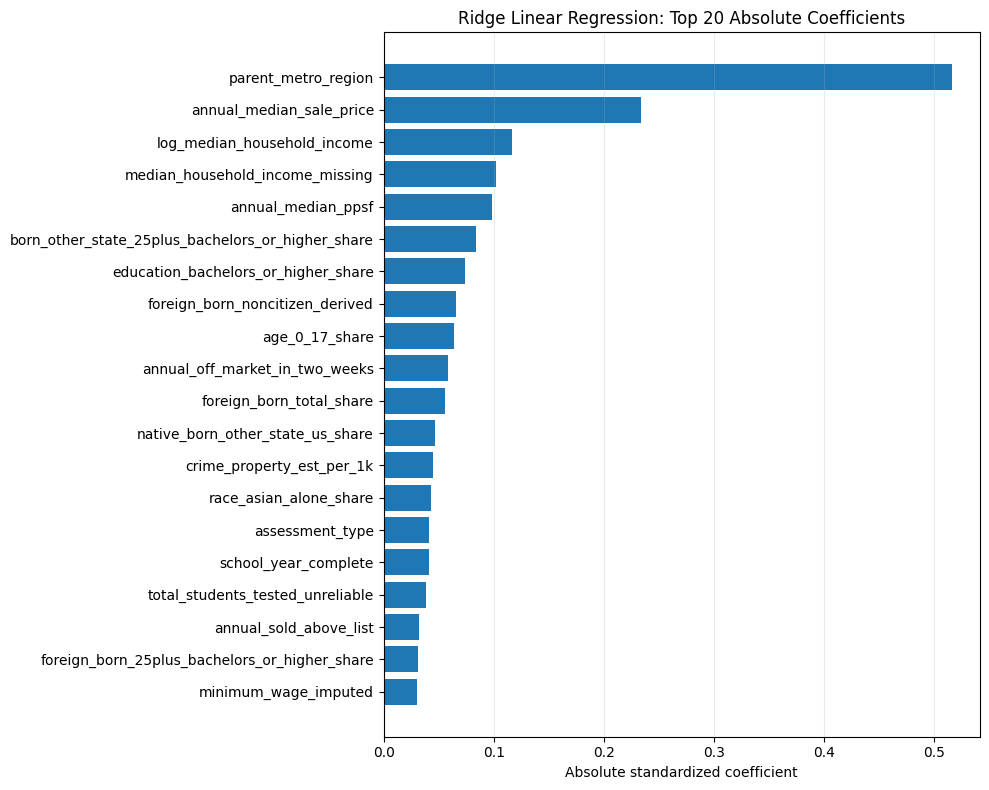

In [8]:
primary_model = 'ridge_linear_regression'
plot_df = (
    feature_coefficients[feature_coefficients['model'].eq(primary_model)]
    .head(20)
    .iloc[::-1]
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(plot_df['feature'], plot_df['max_abs_coefficient'])
ax.set_title('Ridge Linear Regression: Top 20 Absolute Coefficients')
ax.set_xlabel('Absolute standardized coefficient')
ax.grid(axis='x', alpha=0.25)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'ridge_top20_coefficients.png', dpi=200)
plt.show()

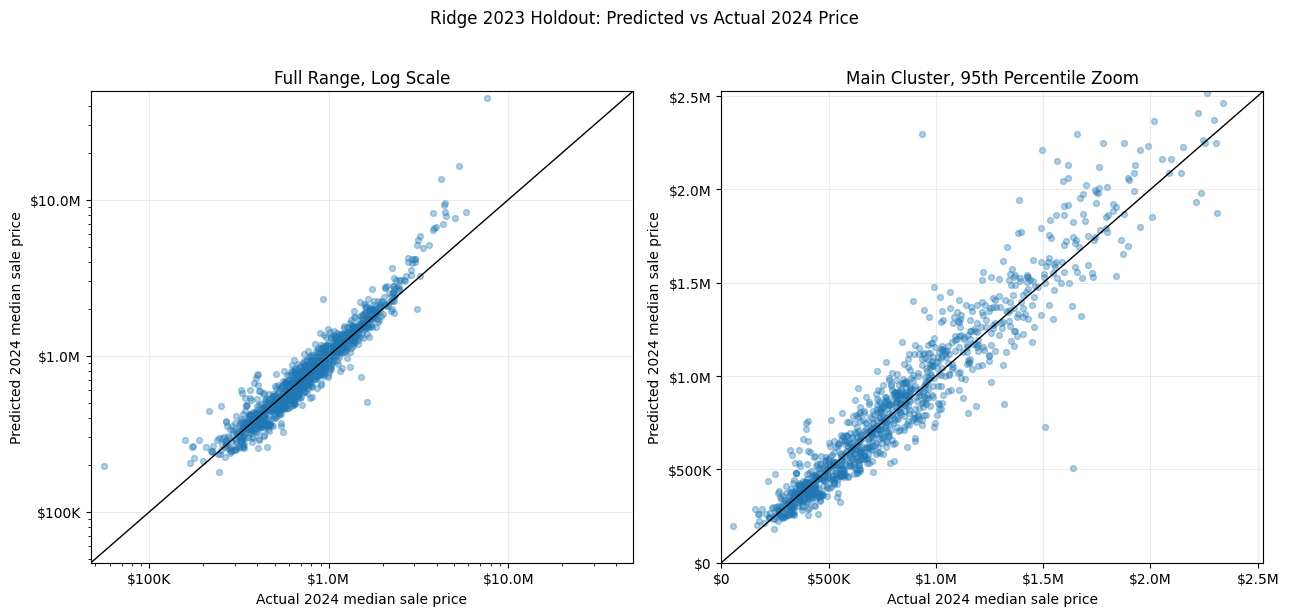

In [9]:
from matplotlib.ticker import FuncFormatter

ridge_predictions = holdout_predictions[holdout_predictions['model'].eq(primary_model)].copy()
actual_price = ridge_predictions[TARGET_DOLLARS]
predicted_price = ridge_predictions['pred_next_year_median_sale_price']

def compact_dollars(value, _):
    if value >= 1_000_000:
        return f'${value / 1_000_000:.1f}M'
    if value >= 1_000:
        return f'${value / 1_000:.0f}K'
    return f'${value:.0f}'

dollar_formatter = FuncFormatter(compact_dollars)
positive_mask = actual_price.gt(0) & predicted_price.gt(0)
full_lims = [
    min(actual_price[positive_mask].min(), predicted_price[positive_mask].min()) * 0.85,
    max(actual_price[positive_mask].max(), predicted_price[positive_mask].max()) * 1.10,
]
zoom_limit = max(actual_price.quantile(0.95), predicted_price.quantile(0.95)) * 1.10

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

axes[0].scatter(actual_price, predicted_price, alpha=0.35, s=18)
axes[0].plot(full_lims, full_lims, color='black', linewidth=1)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlim(full_lims)
axes[0].set_ylim(full_lims)
axes[0].set_title('Full Range, Log Scale')

axes[1].scatter(actual_price, predicted_price, alpha=0.35, s=18)
axes[1].plot([0, zoom_limit], [0, zoom_limit], color='black', linewidth=1)
axes[1].set_xlim(0, zoom_limit)
axes[1].set_ylim(0, zoom_limit)
axes[1].set_title('Main Cluster, 95th Percentile Zoom')

for ax in axes:
    ax.set_xlabel('Actual 2024 median sale price')
    ax.set_ylabel('Predicted 2024 median sale price')
    ax.xaxis.set_major_formatter(dollar_formatter)
    ax.yaxis.set_major_formatter(dollar_formatter)
    ax.grid(alpha=0.25)

fig.suptitle('Ridge 2023 Holdout: Predicted vs Actual 2024 Price', y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'ridge_2023_predicted_vs_actual.png', dpi=200, bbox_inches='tight')
plt.show()

## Output Files

After running all cells, the key files are:

- `linear_regression_cv_metrics.csv`
- `linear_regression_cv_summary.csv`
- `linear_regression_2023_holdout_metrics.csv`
- `linear_regression_2023_holdout_predictions.csv`
- `linear_regression_coefficients_transformed.csv`
- `linear_regression_coefficients_by_feature.csv`
- `ridge_top20_coefficients.png`
- `ridge_2023_predicted_vs_actual.png`